In [1]:
import getdist.plots as gdplt
from cobaya import load_samples
import matplotlib.pyplot as plt
import numpy as np
import camb
import cosmoprimo
import matplotlib.cm as cm
import matplotlib.colors as mcolors

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12)
plt.rc('font', size=14)
plt.rc('axes', labelsize=16)

In [45]:
def get_DESI_errors():
    dict_distance, z_DESI, path = get_DESI_data()

    cov_mat = np.loadtxt(path.replace('mean', 'cov'))

    errors = {}
    for i in range(len(cov_mat[0, :])):
        z = z_DESI[i//2]
        if i == 0:
            _, _, DVfid = get_DESI_fid(z)
            a_iso_err = np.sqrt(cov_mat[i][i]) / DVfid
            errors[z] = {'d_iso': a_iso_err,
                         'd_AP': np.nan,
                         'd_perp': np.nan,
                         'd_par': np.nan
                         }
        elif i%2 == 0:
            cov = [[cov_mat[i-1, i-1], cov_mat[i-1, i]], [cov_mat[i, i-1], cov_mat[i, i]]]
            sig_x = np.sqrt(cov[0][0])
            sig_y = np.sqrt(cov[1][1])

            DMfid, DHfid, DVfid = get_DESI_fid(z)
            if i == len(cov_mat[0, :])-1:
                d_a_perp = sig_y / DMfid
                d_a_par = sig_x / DHfid                
            else :
                d_a_perp = sig_x / DMfid
                d_a_par = sig_y / DHfid

            DM = dict_distance[z]['DM_over_rs']
            DH = dict_distance[z]['DH_over_rs']
            DV = (z*DM**2*DH)**(1/3)

            a_perp = DM / DMfid
            a_par = DH / DHfid
            a_iso = DV / DVfid
            a_AP = a_par / a_perp

            d_a_AP = a_AP * np.sqrt((d_a_par / a_par)**2 + (d_a_perp / a_perp)**2)
            d_a_iso = a_iso * np.sqrt((2/3)**3 * (d_a_perp / a_perp)**2 + (1/3)**2 * (d_a_par / a_par)**2)

            errors[z] = {'d_perp':  d_a_perp,
                         'd_par':   d_a_par,
                         'd_AP':    d_a_AP,
                         'd_iso':   d_a_iso
                         }
    return errors, z_DESI

def get_DESI_data():
    z_DESI = []
    path = r'..\..\COBAYA_packages\data\bao_data\desi_bao_dr2\desi_gaussian_bao_ALL_GCcomb_mean.txt'
    with open(path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            parts = line.split()
            z_DESI.append(float(parts[0]))

    z_DESI = set(z_DESI)
    z_DESI = list(z_DESI)
    z_DESI.sort()
    dict_distance = {}
    for z in z_DESI:
        dict_distance[z] = {}

    with open(path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            parts = line.split()
            z = float(parts[0])
            for key in dict_distance.keys():
                if key == z:
                    dict_distance[key][parts[2]] = float(parts[1])
    
    return dict_distance, z_DESI, path

def get_DESI_fid(redshift):
    DESI = cosmoprimo.fiducial.DESI(engine='camb')
    DESI_bkg = DESI.get_background()
    DESI_thermo = DESI.get_thermodynamics()
    rdrag_fid = DESI_thermo.rs_drag
    DM_fid = DESI_bkg.comoving_angular_distance(redshift)
    DH_fid = 1 / DESI_bkg.efunc(redshift) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
    DV_fid = (redshift * DM_fid**2 * DH_fid)**(1/3)
    DMover_rd_fid = DM_fid / rdrag_fid
    DHover_rd_fid = DH_fid / rdrag_fid
    DVover_rd_fid = DV_fid / rdrag_fid

    return DMover_rd_fid, DHover_rd_fid, DVover_rd_fid

def alpha_ratio(data):
    a_iso = {}
    a_AP = {}
    a_perp = {}
    a_par = {}

    for key in data:
        DV = False
        for subkey in data[key]:
            if subkey == 'DV_over_rs':
                DV = True
        if DV:
            _, _, DV_fid = get_DESI_fid(key)
            a_iso[key] = data[key]['DV_over_rs'] / DV_fid
            a_perp[key] = np.nan
            a_par[key] = np.nan
            a_AP[key] = np.nan
        else:
            DM = data[key]['DM_over_rs']
            DH = data[key]['DH_over_rs']
            DM_fid, DH_fid, _ = get_DESI_fid(key)
            a_perp[key] = DM / DM_fid
            a_par[key] = DH / DH_fid
            a_iso[key] = (DM**2*DH)**(1/3) / (DM_fid**2*DH_fid)**(1/3)
            a_AP[key] = a_par[key] / a_perp[key]
        
    return a_iso, a_AP, a_perp, a_par

In [23]:
A, _, _ = get_DESI_data()

In [30]:
alphas = alpha_ratio(A)

In [46]:
errors, z_DESI = get_DESI_errors()

In [47]:
print(errors)

{0.295: {'d_iso': np.float64(0.009443805186345236), 'd_AP': nan, 'd_perp': nan, 'd_par': nan}, 0.51: {'d_perp': np.float64(0.012470644654042889), 'd_par': np.float64(0.01885904507329651), 'd_AP': np.float64(0.022164470794711507), 'd_iso': np.float64(0.009311219850889802)}, 0.706: {'d_perp': np.float64(0.010164792451377339), 'd_par': np.float64(0.016552939454103098), 'd_AP': np.float64(0.019731529337334193), 'd_iso': np.float64(0.007835268456705378)}, 0.934: {'d_perp': np.float64(0.007355176867306331), 'd_par': np.float64(0.011442886353762142), 'd_AP': np.float64(0.013964362169841288), 'd_iso': np.float64(0.005512107843048921)}, 1.321: {'d_perp': np.float64(0.011557178886058698), 'd_par': np.float64(0.01596541083642338), 'd_AP': np.float64(0.02023073569667844), 'd_iso': np.float64(0.008223888113314702)}, 1.484: {'d_perp': np.float64(0.025219432708804546), 'd_par': np.float64(0.04021848595189285), 'd_AP': np.float64(0.0469391250482571), 'd_iso': np.float64(0.019226258247815334)}, 2.33: {

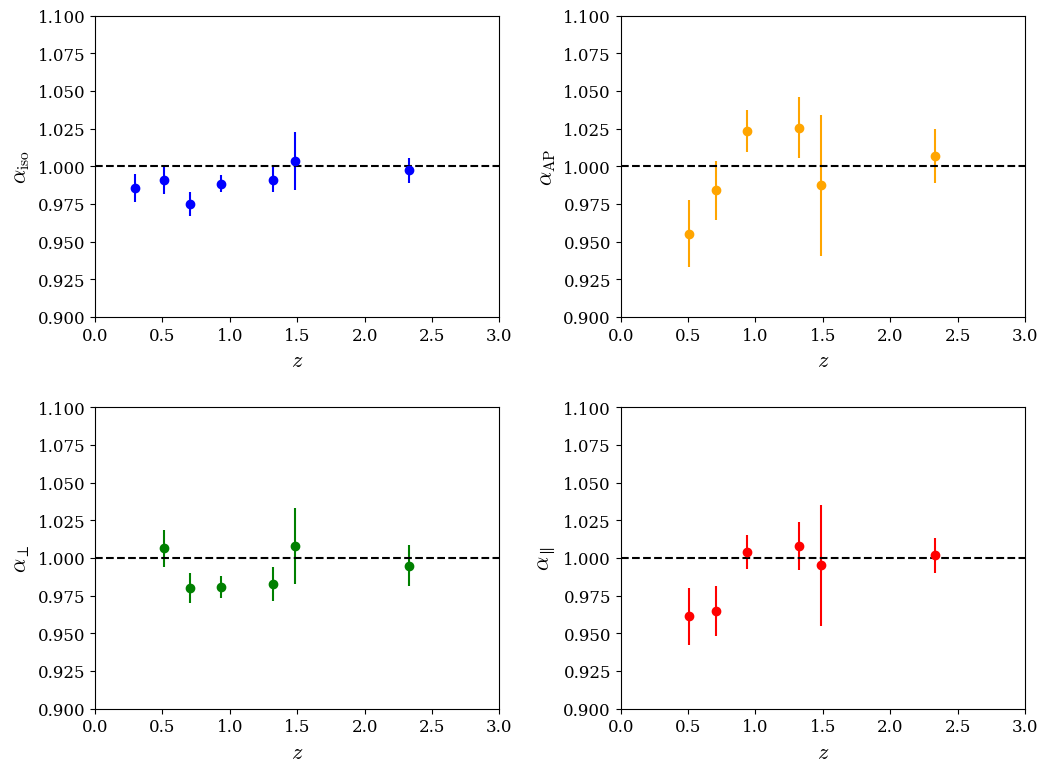

In [50]:
fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(
        2, 2,
    wspace=0.3, hspace=0.3
)
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1])

ax00.errorbar(z_DESI, [alphas[0][key] for key in z_DESI], yerr=[errors[key]['d_iso'] for key in z_DESI], fmt='o', color='blue', label=r'$\alpha_\mathrm{iso}$')
ax00.set_xlabel(r'$z$')
ax00.set_ylabel(r'$\alpha_\mathrm{iso}$')

ax01.errorbar(z_DESI, [alphas[1][key] for key in z_DESI], yerr=[errors[key]['d_AP'] for key in z_DESI], fmt='o', color='orange', label=r'$\alpha_\mathrm{AP}$')
ax01.set_xlabel(r'$z$')
ax01.set_ylabel(r'$\alpha_\mathrm{AP}$')

ax10.errorbar(z_DESI, [alphas[2][key] for key in z_DESI], yerr=[errors[key]['d_perp'] for key in z_DESI], fmt='o', color='green', label=r'$\alpha_\perp$')
ax10.set_xlabel(r'$z$')
ax10.set_ylabel(r'$\alpha_\perp$')

ax11.errorbar(z_DESI, [alphas[3][key] for key in z_DESI], yerr=[errors[key]['d_par'] for key in z_DESI], fmt='o', color='red', label=r'$\alpha_\parallel$')
ax11.set_xlabel(r'$z$')
ax11.set_ylabel(r'$\alpha_\parallel$')

for ax in [ax00, ax01, ax10, ax11]:
    ax.axhline(1, color='black', linestyle='--')
    ax.set_xlim(0, 3)
    ax.set_ylim(0.9, 1.1)

In [21]:
for key in A:
    for subkey in A[key]:
        print(subkey)
        print(A[key][subkey])
    # print(A[key])

DV_over_rs
7.94167639
DM_over_rs
13.58758434
DH_over_rs
21.86294686
DM_over_rs
17.35069094
DH_over_rs
19.45534918
DM_over_rs
21.57563956
DH_over_rs
17.64149464
DM_over_rs
27.60085612
DH_over_rs
14.17602155
DM_over_rs
30.51190063
DH_over_rs
12.81699964
DH_over_rs
8.631545674846294
DM_over_rs
38.988973961958784
